#
<h1 align="center">INTERNET OF THINGS</h1>
<h4 align="center">Mobin khatib(11114435)- Ali Edareh Heidarabadi(11036028)</h4>
<h4 align="center">Politecnico di Milano, Spring 2026</h4>

<h4 align="center">Challenge 2 - Part 1 - Packet Sniffing</h4>




This script parses .pcapng files to decode CoAP, MQTT, MQTT-SN, and DNS traffic.
It answers 8 specific analysis questions (CQ1 to CQ8) based on network traces.


# --- SECTION 1: IMPORTS & GLOBAL CONFIGURATION ---


In [ ]:
import argparse
import ipaddress
import json
import socket
import struct
from collections import Counter, defaultdict

try:
    import matplotlib.pyplot as plt
except Exception:  # pragma: no cover - plotting is optional at runtime
    plt = None

# --- SECTION 2: PCAPNG & LINK LAYER PARSING ---

In [ ]:
FILE_A = "A.pcapng"
FILE_B = "B.pcapng"

COAP_PORT = 5683
COAP_ME_IP = "134.102.218.18"
LOCAL_COAP_SERVER_IP = "127.0.0.1"

MQTT_PORT = 1883
BROKER_PORT_MQTTSN = 1885
HIVEMQ_HOSTNAME = "broker.hivemq.com"
LOCAL_BROKER_IPS = {"127.0.0.1", "::1"}

LINKTYPE_ETHERNET = 1
LINKTYPE_LINUX_SLL = 113

MQTTSN_TYPES = {
    0x00: "ADVERTISE",
    0x01: "SEARCHGW",
    0x02: "GWINFO",
    0x04: "CONNECT",
    0x05: "CONNACK",
    0x06: "WILLTOPICREQ",
    0x07: "WILLTOPIC",
    0x08: "WILLMSGREQ",
    0x09: "WILLMSG",
    0x0A: "REGISTER",
    0x0B: "REGACK",
    0x0C: "PUBLISH",
    0x0D: "PUBACK",
    0x0E: "PUBCOMP",
    0x0F: "PUBREC",
    0x10: "PUBREL",
    0x12: "SUBSCRIBE",
    0x13: "SUBACK",
    0x14: "UNSUBSCRIBE",
    0x15: "UNSUBACK",
    0x16: "PINGREQ",
    0x17: "PINGRESP",
    0x18: "DISCONNECT",
    0x1A: "WILLTOPICUPD",
    0x1B: "WILLTOPICRESP",
    0x1C: "WILLMSGUPD",
    0x1D: "WILLMSGRESP",
    0xFE: "ENCAPSULATED",
}


In [ ]:
def read_pcapng(path):
    """
    Reads a .pcapng file, handles byte-order (endianness), and extracts packets.
    Returns an iterator yielding (timestamp, linktype, raw_packet).
    """
    with open(path, "rb") as handle:
        endian = "<"
        interfaces = []

        while True:
            header = handle.read(8)
            if len(header) < 8:
                break

            block_type_le, block_len_le = struct.unpack("<II", header)

            if block_type_le == 0x0A0D0D0A:
                body = handle.read(block_len_le - 12)
                handle.read(4)
                bom = body[:4]
                if bom == b"\x4d\x3c\x2b\x1a":
                    endian = "<"
                elif bom == b"\x1a\x2b\x3c\x4d":
                    endian = ">"
                else:
                    raise ValueError("Invalid pcapng byte-order magic")
                continue

            block_type = struct.unpack(endian + "I", header[:4])[0]
            block_len = struct.unpack(endian + "I", header[4:8])[0]
            body = handle.read(block_len - 12)
            handle.read(4)

            if block_type == 0x00000001:
                linktype, _, _snaplen = struct.unpack(endian + "HHI", body[:8])
                tsresol = 1e-6
                offset = 8

                while offset + 4 <= len(body):
                    code, length = struct.unpack(endian + "HH", body[offset:offset + 4])
                    offset += 4
                    if code == 0:
                        break

                    value = body[offset:offset + length]
                    offset += ((length + 3) // 4) * 4

                    if code == 9 and length >= 1:
                        raw = value[0]
                        tsresol = 2 ** -(raw & 0x7F) if raw & 0x80 else 10 ** (-raw)

                interfaces.append({"linktype": linktype, "tsresol": tsresol})

            elif block_type == 0x00000006:
                if_id, ts_hi, ts_lo, caplen, _origlen = struct.unpack(
                    endian + "IIIII", body[:20]
                )
                packet = body[20:20 + caplen]
                ts = ((ts_hi << 32) | ts_lo) * interfaces[if_id]["tsresol"]
                yield ts, interfaces[if_id]["linktype"], packet


def parse_link_layer(linktype, packet):
    """
    Strips the link-layer header (Ethernet or Linux SLL) to extract the Network layer.
    Returns (protocol_type, l3_packet_payload).
    """
    if linktype == LINKTYPE_LINUX_SLL:
        if len(packet) < 16:
            return None, None
        protocol = struct.unpack("!H", packet[14:16])[0]
        return protocol, packet[16:]

    if linktype == LINKTYPE_ETHERNET:
        if len(packet) < 14:
            return None, None
        protocol = struct.unpack("!H", packet[12:14])[0]
        return protocol, packet[14:]

    return None, None


# --- SECTION 3: NETWORK & TRANSPORT LAYER (IP, UDP, TCP) ---

In [ ]:
def parse_ip(protocol, packet):
    """
    Parses IPv4 and IPv6 headers to extract source/destination IPs and protocol type.
    Returns a dictionary containing IP metadata and payload.
    """
    if protocol == 0x0800:
        if len(packet) < 20:
            return None

        version = packet[0] >> 4
        ihl = (packet[0] & 0x0F) * 4
        if version != 4 or len(packet) < ihl:
            return None

        total_length = struct.unpack("!H", packet[2:4])[0]
        if total_length < ihl:
            return None

        return {
            "version": 4,
            "proto": packet[9],
            "src": str(ipaddress.IPv4Address(packet[12:16])),
            "dst": str(ipaddress.IPv4Address(packet[16:20])),
            "payload": packet[ihl:total_length],
        }

    if protocol == 0x86DD:
        if len(packet) < 40:
            return None

        version = packet[0] >> 4
        if version != 6:
            return None

        payload_length = struct.unpack("!H", packet[4:6])[0]
        return {
            "version": 6,
            "proto": packet[6],
            "src": str(ipaddress.IPv6Address(packet[8:24])),
            "dst": str(ipaddress.IPv6Address(packet[24:40])),
            "payload": packet[40:40 + payload_length],
        }

    return None


def parse_udp(payload):
    """
    Parses UDP headers to extract source and destination ports.
    """
    if len(payload) < 8:
        return None

    sport, dport, length, _checksum = struct.unpack("!HHHH", payload[:8])
    if length < 8 or len(payload) < length:
        return None

    return {
        "sport": sport,
        "dport": dport,
        "payload": payload[8:length],
    }


def parse_tcp(payload):
    """
    Parses TCP headers to extract ports, sequence/acknowledgment numbers, and flags.
    """
    if len(payload) < 20:
        return None

    sport, dport, seq, ack, off_flags, window, checksum, urgent = struct.unpack(
        "!HHIIHHHH", payload[:20]
    )
    data_offset = ((off_flags >> 12) & 0x0F) * 4
    flags = off_flags & 0x01FF

    if len(payload) < data_offset:
        return None

    return {
        "sport": sport,
        "dport": dport,
        "seq": seq,
        "ack": ack,
        "flags": flags,
        "window": window,
        "checksum": checksum,
        "urgent": urgent,
        "payload": payload[data_offset:],
    }


def iter_ip_records(path):
    """
    Helper generator that reads the PCAPNG file and filters out non-IP packets.
    Yields (timestamp, ip_dictionary).
    """
    for ts, linktype, raw_packet in read_pcapng(path):
        protocol, l3_packet = parse_link_layer(linktype, raw_packet)
        if protocol is None:
            continue

        ip = parse_ip(protocol, l3_packet)
        if ip is None:
            continue

        yield ts, ip


# --- SECTION 4: APPLICATION LAYER - CoAP PARSING ---

In [ ]:
def parse_extended(value, data, index):
    """
    Helper function to parse extended option fields in CoAP headers.
    """
    if value < 13:
        return value, index
    if value == 13:
        return 13 + data[index], index + 1
    if value == 14:
        return 269 + struct.unpack("!H", data[index:index + 2])[0], index + 2
    raise ValueError("Reserved CoAP option encoding")


def parse_coap(data):
    """
    Decodes a raw UDP payload into a CoAP message structure (Version, Type, Code, MID, Token, Options).
    Returns a dictionary of CoAP fields or None if invalid.
    """
    if len(data) < 4:
        return None

    first = data[0]
    version = (first >> 6) & 0x03
    message_type = (first >> 4) & 0x03
    token_length = first & 0x0F
    code = data[1]
    mid = struct.unpack("!H", data[2:4])[0]

    if version != 1 or len(data) < 4 + token_length:
        return None

    token = data[4:4 + token_length]
    index = 4 + token_length
    option_number = 0
    options = []
    payload = b""

    while index < len(data):
        if data[index] == 0xFF:
            payload = data[index + 1:]
            break

        current = data[index]
        index += 1

        delta_n = (current >> 4) & 0x0F
        length_n = current & 0x0F

        delta, index = parse_extended(delta_n, data, index)
        length, index = parse_extended(length_n, data, index)

        option_number += delta
        value = data[index:index + length]
        index += length
        options.append((option_number, value))

    return {
        "type": message_type,
        "code": code,
        "mid": mid,
        "token": token,
        "options": options,
        "payload": payload,
    }


def code_to_string(code):
    """
    Converts a numeric CoAP code into its human-readable string representation (e.g., 2.05).
    """
    if code <= 31:
        return {
            1: "GET",
            2: "POST",
            3: "PUT",
            4: "DELETE",
        }.get(code, f"REQ({code})")
    return f"{code >> 5}.{code & 31:02d}"


def get_uri_path(options):
    """
    Extracts and reconstructs the URI-Path string from CoAP options (Option Number 11).
    """
    parts = [value.decode("utf-8", errors="ignore") for number, value in options if number == 11]
    return "/" + "/".join(parts) if parts else "/"


def get_option_values(options, number):
    """
    Retrieves all values for a specific CoAP option number.
    """
    return [value for opt_number, value in options if opt_number == number]


def extract_observe_value(payload):
    """
    Attempts to extract the 'value' field from a JSON payload, typical in Observe notifications.
    """
    try:
        parsed = json.loads(payload.decode("utf-8"))
        if isinstance(parsed, list) and parsed and isinstance(parsed[0], dict):
            return parsed[0].get("value")
    except Exception:
        pass
    return payload.decode("utf-8", errors="ignore")


def collect_coap_events(path):
    """
    Scans the packet capture for all valid CoAP messages over UDP and returns them as a sorted list.
    """
    events = []

    for ts, ip in iter_ip_records(path):
        if ip["proto"] != 17:
            continue

        udp = parse_udp(ip["payload"])
        if udp is None:
            continue

        if udp["sport"] != COAP_PORT and udp["dport"] != COAP_PORT:
            continue

        try:
            coap = parse_coap(udp["payload"])
        except Exception:
            continue

        if not coap:
            continue

        events.append(
            {
                "ts": ts,
                "src": ip["src"],
                "dst": ip["dst"],
                "sport": udp["sport"],
                "dport": udp["dport"],
                **coap,
            }
        )

    events.sort(key=lambda entry: entry["ts"])
    return events


def find_coap_response(request, events):
    """
    Searches through collected CoAP events to find a matching response for a given request
    using Message ID (MID) or Token.
    """
    for event in events:
        if event["ts"] <= request["ts"]:
            continue
        if (
            event["src"] == request["dst"]
            and event["dst"] == request["src"]
            and event["sport"] == request["dport"]
            and event["dport"] == request["sport"]
            and event["mid"] == request["mid"]
            and event["code"] > 31
        ):
            return event

    for event in events:
        if event["ts"] <= request["ts"]:
            continue
        if (
            event["src"] == request["dst"]
            and event["dst"] == request["src"]
            and event["sport"] == request["dport"]
            and event["dport"] == request["sport"]
            and event["token"] == request["token"]
            and event["code"] > 31
        ):
            return event

    return None


# --- SECTION 5: APPLICATION LAYER - DNS PARSING ---

In [ ]:
def parse_dns_name(data, pos):
    """
    Parses a DNS domain name from the payload, handling DNS pointer compression.
    """
    labels = []
    jumped = False
    return_pos = pos
    visited = set()

    while True:
        if pos >= len(data):
            raise ValueError("Invalid DNS name")

        length = data[pos]

        if length == 0:
            pos += 1
            if not jumped:
                return_pos = pos
            break

        if length & 0xC0 == 0xC0:
            if pos + 1 >= len(data):
                raise ValueError("Invalid DNS pointer")
            pointer = ((length & 0x3F) << 8) | data[pos + 1]
            if pointer in visited:
                raise ValueError("DNS pointer loop")
            visited.add(pointer)
            if not jumped:
                return_pos = pos + 2
            pos = pointer
            jumped = True
            continue

        pos += 1
        if pos + length > len(data):
            raise ValueError("Invalid DNS label length")
        labels.append(data[pos:pos + length].decode("ascii", errors="replace"))
        pos += length

    return ".".join(labels), return_pos


def parse_dns(payload):
    """
    Decodes DNS queries and answers to extract requested domains and resolved IP addresses.
    """
    if len(payload) < 12:
        return None

    _tid, _flags, qdcount, ancount, _nscount, _arcount = struct.unpack("!HHHHHH", payload[:12])
    pos = 12

    questions = []
    for _ in range(qdcount):
        qname, pos = parse_dns_name(payload, pos)
        qtype, qclass = struct.unpack("!HH", payload[pos:pos + 4])
        pos += 4
        questions.append((qname, qtype, qclass))

    answers = []
    for _ in range(ancount):
        name, pos = parse_dns_name(payload, pos)
        atype, aclass, ttl, rdlen = struct.unpack("!HHIH", payload[pos:pos + 10])
        pos += 10
        rdata = payload[pos:pos + rdlen]
        pos += rdlen

        value = None
        if atype == 1 and rdlen == 4:
            value = str(ipaddress.IPv4Address(rdata))
        elif atype == 28 and rdlen == 16:
            value = str(ipaddress.IPv6Address(rdata))

        answers.append((name, atype, value, ttl, aclass))

    return {"questions": questions, "answers": answers}


def discover_hivemq_ips(path):
    """
    Searches DNS traffic to find all IPv4/IPv6 addresses resolved for 'broker.hivemq.com'.
    Returns a set of IP addresses.
    """
    ips = set()

    for _ts, ip in iter_ip_records(path):
        if ip["proto"] != 17:
            continue

        udp = parse_udp(ip["payload"])
        if udp is None:
            continue

        if udp["sport"] != 53 and udp["dport"] != 53:
            continue

        try:
            dns = parse_dns(udp["payload"])
        except Exception:
            continue

        if not dns:
            continue

        if not any(question[0] == HIVEMQ_HOSTNAME for question in dns["questions"]):
            continue

        for name, _atype, value, _ttl, _aclass in dns["answers"]:
            if name == HIVEMQ_HOSTNAME and value is not None:
                ips.add(value)

    return ips


# --- SECTION 6: APPLICATION LAYER - MQTT PARSING & TCP REASSEMBLY ---

In [ ]:
def decode_utf8(data, pos):
    """
    Decodes MQTT specific UTF-8 string fields.
    """
    if pos + 2 > len(data):
        raise ValueError("Incomplete MQTT UTF-8 field")

    length = struct.unpack("!H", data[pos:pos + 2])[0]
    pos += 2
    if pos + length > len(data):
        raise ValueError("Invalid MQTT UTF-8 field length")

    value = data[pos:pos + length].decode("utf-8", errors="replace")
    pos += length
    return value, pos


def decode_varint(data, pos=0):
    """
    Decodes MQTT Remaining Length field (Variable Byte Integer).
    """
    multiplier = 1
    value = 0
    consumed = 0

    while True:
        if pos + consumed >= len(data):
            raise ValueError("Incomplete MQTT varint")

        current = data[pos + consumed]
        value += (current & 0x7F) * multiplier
        consumed += 1

        if (current & 0x80) == 0:
            return value, consumed

        multiplier *= 128
        if consumed >= 4:
            raise ValueError("Invalid MQTT varint")


def parse_mqtt_packets(stream):
    packets = []
    offset = 0

    while offset < len(stream):
        if offset + 2 > len(stream):
            break

        first = stream[offset]
        remaining_length, varint_len = decode_varint(stream, offset + 1)
        total_len = 1 + varint_len + remaining_length

        if offset + total_len > len(stream):
            break

        payload = stream[offset + 1 + varint_len:offset + total_len]
        packets.append((offset, first, payload))
        offset += total_len

    return packets


def parse_connect(payload):
    pos = 0
    _proto_name, pos = decode_utf8(payload, pos)
    proto_level = payload[pos]
    pos += 1
    flags = payload[pos]
    pos += 1
    _keepalive = struct.unpack("!H", payload[pos:pos + 2])[0]
    pos += 2

    if proto_level == 5:
        properties_len, consumed = decode_varint(payload, pos)
        pos += consumed + properties_len

    client_id, pos = decode_utf8(payload, pos)

    will_topic = None
    will_message = None

    if flags & 0x04:
        if proto_level == 5:
            will_properties_len, consumed = decode_varint(payload, pos)
            pos += consumed + will_properties_len

        will_topic, pos = decode_utf8(payload, pos)
        if pos + 2 > len(payload):
            raise ValueError("Incomplete will payload length")
        message_length = struct.unpack("!H", payload[pos:pos + 2])[0]
        pos += 2
        will_message = payload[pos:pos + message_length]
        pos += message_length

    return {
        "type": "CONNECT",
        "proto_level": proto_level,
        "client_id": client_id,
        "will_flag": bool(flags & 0x04),
        "will_topic": will_topic,
        "will_message": will_message,
    }


def parse_subscribe(payload, version):
    pos = 0
    packet_id = struct.unpack("!H", payload[pos:pos + 2])[0]
    pos += 2

    if version == 5:
        properties_len, consumed = decode_varint(payload, pos)
        pos += consumed + properties_len

    topics = []
    while pos < len(payload):
        topic_filter, pos = decode_utf8(payload, pos)
        options = payload[pos]
        pos += 1
        topics.append((topic_filter, options))

    return {
        "type": "SUBSCRIBE",
        "packet_id": packet_id,
        "topics": topics,
    }


def parse_unsubscribe(payload, version):
    pos = 0
    packet_id = struct.unpack("!H", payload[pos:pos + 2])[0]
    pos += 2

    if version == 5:
        properties_len, consumed = decode_varint(payload, pos)
        pos += consumed + properties_len

    topics = []
    while pos < len(payload):
        topic_filter, pos = decode_utf8(payload, pos)
        topics.append(topic_filter)

    return {
        "type": "UNSUBSCRIBE",
        "packet_id": packet_id,
        "topics": topics,
    }


def parse_publish(first, payload, version):
    qos = (first >> 1) & 0x03
    retain = bool(first & 0x01)
    dup = bool(first & 0x08)

    pos = 0
    topic, pos = decode_utf8(payload, pos)

    packet_id = None
    if qos > 0:
        packet_id = struct.unpack("!H", payload[pos:pos + 2])[0]
        pos += 2

    if version == 5:
        properties_len, consumed = decode_varint(payload, pos)
        pos += consumed + properties_len

    return {
        "type": "PUBLISH",
        "topic": topic,
        "payload": payload[pos:],
        "qos": qos,
        "retain": retain,
        "dup": dup,
        "packet_id": packet_id,
    }


def parse_mqtt_packet(first, payload, version):
    packet_type = first >> 4

    if packet_type == 1:
        return parse_connect(payload)
    if packet_type == 3:
        return parse_publish(first, payload, version)
    if packet_type == 8:
        return parse_subscribe(payload, version)
    if packet_type == 10:
        return parse_unsubscribe(payload, version)
    if packet_type == 14:
        return {"type": "DISCONNECT"}

    return {"type": f"TYPE_{packet_type}"}


def topic_matches(filter_str, topic):
    """
    Checks if a given MQTT topic matches a subscription filter containing wildcards (+ or #).
    """
    filter_levels = filter_str.split("/")
    topic_levels = topic.split("/")

    index = 0
    while index < len(filter_levels):
        current_filter = filter_levels[index]

        if current_filter == "#":
            return index == len(filter_levels) - 1

        if index >= len(topic_levels):
            return False

        if current_filter != "+" and current_filter != topic_levels[index]:
            return False

        index += 1

    return index == len(topic_levels)


def has_wildcard(topic_filter):
    return "+" in topic_filter or "#" in topic_filter


def wildcard_count(topic_filter):
    return topic_filter.count("+") + topic_filter.count("#")


def reassemble_stream(segments):
    """
    Reassembles a fragmented TCP stream into a continuous byte array based on Sequence Numbers.
    """
    ordered = sorted(segments, key=lambda item: (item["seq"], item["ts"]))
    stream = bytearray()
    ranges = []
    current_seq_end = None

    for segment in ordered:
        seq = segment["seq"]
        payload = segment["payload"]
        ts = segment["ts"]

        if not payload:
            continue

        if current_seq_end is None:
            start = len(stream)
            stream.extend(payload)
            end = len(stream)
            ranges.append((start, end, ts))
            current_seq_end = seq + len(payload)
            continue

        if seq >= current_seq_end:
            start = len(stream)
            stream.extend(payload)
            end = len(stream)
            ranges.append((start, end, ts))
            current_seq_end = seq + len(payload)
        else:
            overlap = current_seq_end - seq
            if overlap < len(payload):
                start = len(stream)
                stream.extend(payload[overlap:])
                end = len(stream)
                ranges.append((start, end, ts))
                current_seq_end += len(payload) - overlap

    return bytes(stream), ranges


def ts_for_offset(ranges, offset):
    for start, end, ts in ranges:
        if start <= offset < end:
            return ts
    return ranges[-1][2] if ranges else None


def collect_tcp_segments(path, port):
    by_dir = defaultdict(list)

    for ts, ip in iter_ip_records(path):
        if ip["proto"] != 6:
            continue

        tcp = parse_tcp(ip["payload"])
        if tcp is None:
            continue

        if tcp["sport"] != port and tcp["dport"] != port:
            continue

        key = (ip["src"], tcp["sport"], ip["dst"], tcp["dport"])
        by_dir[key].append(
            {
                "seq": tcp["seq"],
                "ts": ts,
                "payload": tcp["payload"],
            }
        )

    return by_dir


def collect_mqtt_connections(path):
    """
    Reconstructs full MQTT client-broker sessions by reassembling TCP streams in both directions.
    Extracts and parses all MQTT packets within each connection.
    """
    by_dir = collect_tcp_segments(path, MQTT_PORT)
    connections = []
    seen = set()

    for src_ip, sport, dst_ip, dport in by_dir.keys():
        if dport == MQTT_PORT:
            client_ep = (src_ip, sport)
            broker_ep = (dst_ip, dport)
        elif sport == MQTT_PORT:
            client_ep = (dst_ip, dport)
            broker_ep = (src_ip, sport)
        else:
            continue

        norm = (client_ep, broker_ep)
        if norm in seen:
            continue
        seen.add(norm)

        c2b_key = (client_ep[0], client_ep[1], broker_ep[0], broker_ep[1])
        b2c_key = (broker_ep[0], broker_ep[1], client_ep[0], client_ep[1])

        c2b_stream, c2b_ranges = reassemble_stream(by_dir.get(c2b_key, []))
        b2c_stream, b2c_ranges = reassemble_stream(by_dir.get(b2c_key, []))

        version = 4
        c2b_packets = []
        for offset, first, payload in parse_mqtt_packets(c2b_stream):
            try:
                packet = parse_mqtt_packet(first, payload, version)
            except Exception:
                continue
            if packet["type"] == "CONNECT":
                version = packet["proto_level"]
            packet["_time"] = ts_for_offset(c2b_ranges, offset)
            c2b_packets.append(packet)

        b2c_packets = []
        for offset, first, payload in parse_mqtt_packets(b2c_stream):
            try:
                packet = parse_mqtt_packet(first, payload, version)
            except Exception:
                continue
            packet["_time"] = ts_for_offset(b2c_ranges, offset)
            b2c_packets.append(packet)

        connections.append(
            {
                "client_ep": client_ep,
                "broker_ep": broker_ep,
                "version": version,
                "c2b": c2b_packets,
                "b2c": b2c_packets,
            }
        )

    return connections


# --- SECTION 7: APPLICATION LAYER - MQTT-SN PARSING ---

In [ ]:
def parse_mqttsn(payload):
    """
    Extracts the message type from an MQTT-SN packet payload.
    """
    if not payload:
        return None

    if payload[0] != 0x01:
        if len(payload) < 2:
            return None
        length = payload[0]
        if length != len(payload):
            return None
        return payload[1]

    if len(payload) < 4:
        return None
    length = struct.unpack("!H", payload[1:3])[0]
    if length != len(payload):
        return None
    return payload[3]


def collect_mqttsn_packets(path):
    """
    Scans the packet capture for valid MQTT-SN packets over UDP (Port 1885).
    """
    packets = []

    for ts, ip in iter_ip_records(path):
        if ip["proto"] != 17:
            continue

        udp = parse_udp(ip["payload"])
        if udp is None:
            continue

        if udp["sport"] != BROKER_PORT_MQTTSN and udp["dport"] != BROKER_PORT_MQTTSN:
            continue

        packets.append(
            {
                "ts": ts,
                "src_ip": ip["src"],
                "dst_ip": ip["dst"],
                "src_port": udp["sport"],
                "dst_port": udp["dport"],
                "payload": udp["payload"],
            }
        )

    return packets


def topic_layers(topic):
    """
    Calculates the depth (number of layers) of an MQTT topic string.
    """
    return topic.count("/") + 1 if topic else 0

# --- SECTION 8: PROJECT ANALYSIS MODULES (PARTS 1 TO 8) ---

#8.1: Part 1

In [ ]:
def run_part1(file_a):
    """
    Part 1: Identifies MIDs of successful NON-DELETE requests sent to coap.me.
    """
    events = collect_coap_events(file_a)
    successful_requests = []

    for request in events:
        is_target_request = (
            request["type"] == 1
            and request["code"] == 4
            and request["dst"] == COAP_ME_IP
            and request["dport"] == COAP_PORT
        )
        if not is_target_request:
            continue

        matched_response = None
        for response in events:
            if (
                response["ts"] > request["ts"]
                and response["src"] == request["dst"]
                and response["dst"] == request["src"]
                and response["sport"] == COAP_PORT
                and response["dport"] == request["sport"]
                and response["token"] == request["token"]
            ):
                matched_response = response
                break

        if matched_response and 64 <= matched_response["code"] < 96:
            successful_requests.append((request, matched_response))

    desired_outcome = []
    for request, response in successful_requests:
        if response["code"] == 66:  # Server claims it was deleted (2.02)
            target_uri = get_uri_path(request["options"])
            resource_still_exists = False

            # Check all events AFTER this deletion to see if it actually survived
            for later_req in events:
                if (later_req["ts"] > response["ts"]
                    and later_req["code"] == 1  # GET request
                    and get_uri_path(later_req["options"]) == target_uri):

                    # Find the response to this subsequent GET request
                    for later_resp in events:
                        if (later_resp["ts"] > later_req["ts"]
                            and later_resp["token"] == later_req["token"]):

                            # If the server responds with 2.05 Content (code 69), it lied about deleting it!
                            if later_resp["code"] == 69:
                                resource_still_exists = True
                            break

                if resource_still_exists:
                    break

            # Only count it as a "desired outcome" if the resource actually disappeared
            if not resource_still_exists:
                desired_outcome.append((request, response))

    print("Part 1")
    if successful_requests:
        first_mid = successful_requests[0][0]['mid']
        total_success = len(successful_requests)
        print(f"CQ1a = {total_success} (MID: {first_mid})")
    else:
        print("CQ1a = 0")

    print(f"CQ1b = {len(desired_outcome)}")


#8.2: Part 2

In [ ]:
def run_part2(file_a):
    """
    Part 2: Finds specific CoAP resources where the number of unsuccessful POSTs
    equals the number of unsuccessful PUTs (and is greater than 0).
    """
    events = collect_coap_events(file_a)
    unique_requests = {}

    for event in events:
        is_target_request = (
            event["dst"] == LOCAL_COAP_SERVER_IP
            and event["dport"] == COAP_PORT
            and event["type"] == 0
            and event["code"] in (2, 3)
        )
        if not is_target_request:
            continue

        signature = (
            event["src"],
            event["sport"],
            event["dst"],
            event["dport"],
            event["type"],
            event["code"],
            event["mid"],
            event["token"],
            tuple(event["options"]),
            event["payload"],
        )

        if signature not in unique_requests:
            unique_requests[signature] = event

    requests = sorted(unique_requests.values(), key=lambda entry: entry["ts"])
    per_resource = defaultdict(lambda: {"POST": set(), "PUT": set()})

    for request in requests:
        response = find_coap_response(request, events)
        if response is None:
            continue

        if 64 <= response["code"] < 96:
            continue

        resource = get_uri_path(request["options"])
        method = "POST" if request["code"] == 2 else "PUT"
        req_id = (request["src"], request["sport"], request["mid"], request["token"])
        per_resource[resource][method].add(req_id)

    matching_resources = []
    for resource, counts in per_resource.items():
        post_count = len(counts["POST"])
        put_count = len(counts["PUT"])
        if post_count == put_count and post_count > 0:
            matching_resources.append((resource, post_count, put_count))

    print("Part 2")
    print("Resources with X = Y > 0:")
    for resource, post_count, put_count in sorted(matching_resources):
        print(f"  {resource}: unsuccessful POST={post_count}, unsuccessful PUT={put_count}")
    print()
    print("CQ2 =", len(matching_resources))



# 8.3: Part 3

In [ ]:
def run_part3(file_a):
    """
    Part 3: Analyzes CoAP Observe notifications for the temperature resource.
    Note: Initial (piggybacked) registration responses are explicitly filtered out
    to correctly count only the asynchronous updates. It also calculates wasted
    traffic (CQ3b) by checking for unacknowledged notifications.
    """
    events = collect_coap_events(file_a)
    observe_request = None

    for event in events:
        if (
            event["type"] == 0
            and event["code"] == 1
            and event["dport"] == COAP_PORT
            and get_uri_path(event["options"]) == "/dining_room/temperature"
            and any(value == b"" for value in get_option_values(event["options"], 6))
        ):
            observe_request = event
            break

    if observe_request is None:
        raise RuntimeError("Observe registration for /dining_room/temperature not found")

    notifications = []
    for event in events:
        if (
            event["ts"] >= observe_request["ts"]
            and event["src"] == observe_request["dst"]
            and event["dst"] == observe_request["src"]
            and event["sport"] == COAP_PORT
            and event["dport"] == observe_request["sport"]
            and event["code"] == 69
            and event["token"] == observe_request["token"]
            and get_option_values(event["options"], 6)
        ):
            notifications.append(event)

    unique_notifications = []
    seen = set()
    for notification in notifications:
        # Filter out the initial piggybacked registration response
        if notification["mid"] == observe_request["mid"]:
            continue

        key = (
            notification["mid"],
            tuple(get_option_values(notification["options"], 6)),
            notification["payload"],
        )
        if key in seen:
            continue
        seen.add(key)
        unique_notifications.append(notification)

    print("Part 3")
    print("Observe request:")
    print(
        f"  MID={observe_request['mid']}, "
        f"token={observe_request['token'].hex()}, "
        f"resource={get_uri_path(observe_request['options'])}"
    )
    print()
    print("Distinct observe notifications (retransmissions removed):")

    unacked_count = 0

    for index, notification in enumerate(unique_notifications, start=1):
        # Look for an ACK (type 2) or RST (type 3) from the client back to the server
        client_responded = False
        for event in events:
            if (
                event["ts"] > notification["ts"]
                and event["src"] == notification["dst"]
                and event["dst"] == notification["src"]
                and event["mid"] == notification["mid"]
                and event["type"] in (2, 3)
            ):
                client_responded = True
                break

        status = "ACKed" if client_responded else "NO ACK"
        if not client_responded:
            unacked_count += 1

        observe_values = [value.hex() for value in get_option_values(notification["options"], 6)]
        print(
            f"{index:2d}. ts={notification['ts']:.3f}, "
            f"mid={notification['mid']}, "
            f"observe={observe_values}, "
            f"value={extract_observe_value(notification['payload']):>5}, "
            f"status={status}"
        )
    print()

    cq3b = unacked_count

    print("CQ3a =", len(unique_notifications))
    print(f"CQ3b = {cq3b} (Total unacked packets: {unacked_count})")

#8.4: Part 4

In [ ]:
def run_part4(file_a):
    """
    Part 4: Counts valid MQTT-SN packets involving the local broker port,
    categorized by direction and message type.
    """
    broker_to_clients = 0
    broker_type_counter = Counter()
    all_type_counter = Counter()
    all_to_broker = 0

    for packet in collect_mqttsn_packets(file_a):
        message_type = parse_mqttsn(packet["payload"])
        if message_type is None:
            continue

        type_name = MQTTSN_TYPES.get(message_type, f"TYPE_{message_type}")
        all_type_counter[type_name] += 1

        if packet["src_port"] == BROKER_PORT_MQTTSN:
            broker_to_clients += 1
            broker_type_counter[type_name] += 1

        if packet["dst_port"] == BROKER_PORT_MQTTSN:
            all_to_broker += 1

    print("Part 4")
    print("Valid MQTT-SN packets involving port 1885:", sum(all_type_counter.values()))
    print("Valid client -> broker MQTT-SN packets:", all_to_broker)
    print("Valid broker -> client MQTT-SN packets (CQ4):", broker_to_clients)
    print()
    print("All MQTT-SN types involving port 1885:")
    for name, count in sorted(all_type_counter.items()):
        print(f"  {name}: {count}")
    print()
    print("Broker -> client MQTT-SN types:")
    for name, count in sorted(broker_type_counter.items()):
        print(f"  {name}: {count}")

#8.5: Part 5

In [ ]:
def run_part5(file_b):
    """
    Part 5: Identifies subscribers receiving a 'Last Will' message via a wildcard subscription.
    """
    connections = collect_mqtt_connections(file_b)
    will_registrations = []

    for connection in connections:
        connect_packet = next(
            (packet for packet in connection["c2b"] if packet["type"] == "CONNECT"),
            None,
        )
        if connect_packet and connect_packet["will_flag"]:
            will_registrations.append(
                {
                    "broker_ep": connection["broker_ep"],
                    "owner_client_ep": connection["client_ep"],
                    "owner_client_id": connect_packet["client_id"],
                    "will_topic": connect_packet["will_topic"],
                    "will_message": connect_packet["will_message"],
                }
            )

    subscribers_receiving_will_via_wildcard = set()
    details = []

    for connection in connections:
        connect_packet = next(
            (packet for packet in connection["c2b"] if packet["type"] == "CONNECT"),
            None,
        )
        client_id = connect_packet["client_id"] if connect_packet else str(connection["client_ep"])
        active_filters = []

        merged_events = []
        for packet in connection["c2b"]:
            merged_events.append((packet.get("_time", 0), 0, packet))
        for packet in connection["b2c"]:
            merged_events.append((packet.get("_time", 0), 1, packet))
        merged_events.sort(key=lambda item: (item[0], item[1]))

        for _timestamp, direction, packet in merged_events:
            if direction == 0:
                if packet["type"] == "SUBSCRIBE":
                    for topic_filter, _options in packet["topics"]:
                        active_filters.append(topic_filter)
                elif packet["type"] == "UNSUBSCRIBE":
                    for topic_filter in packet["topics"]:
                        active_filters = [flt for flt in active_filters if flt != topic_filter]
                continue

            if packet["type"] != "PUBLISH":
                continue

            for registration in will_registrations:
                same_broker = connection["broker_ep"] == registration["broker_ep"]
                same_topic = packet["topic"] == registration["will_topic"]
                same_payload = packet["payload"] == registration["will_message"]

                if not (same_broker and same_topic and same_payload):
                    continue

                matching_filters = [
                    flt for flt in active_filters if topic_matches(flt, packet["topic"])
                ]
                wildcard_filters = [flt for flt in matching_filters if has_wildcard(flt)]

                if wildcard_filters:
                    subscribers_receiving_will_via_wildcard.add(client_id)
                    details.append(
                        {
                            "subscriber_client_id": client_id,
                            "subscriber_endpoint": connection["client_ep"],
                            "matched_filter": wildcard_filters[0],
                            "will_topic": packet["topic"],
                            "will_payload": packet["payload"].decode(
                                "utf-8", errors="replace"
                            ),
                            "will_owner_client_id": registration["owner_client_id"],
                        }
                    )
                    break

    print("Part 5")
    print("Subscribers receiving a Last Will message via a wildcard subscription:")
    for detail in details:
        print(
            f"  subscriber={detail['subscriber_client_id']}, "
            f"filter={detail['matched_filter']}, "
            f"topic={detail['will_topic']}, "
            f"payload={detail['will_payload']!r}, "
            f"will_owner={detail['will_owner_client_id']!r}"
        )
    print()
    print("CQ5 =", len(subscribers_receiving_will_via_wildcard))

# 8.6: Part 6

In [ ]:
def run_part6(file_b):
    """
    Part 6: Detects MQTT clients connected to HiveMQ that are erasing retained messages
    (by publishing a 0-byte payload with the retain flag set to true).
    """
    hivemq_ips = discover_hivemq_ips(file_b)
    connections = collect_mqtt_connections(file_b)
    clients_erasing_retained = set()
    details = []

    for connection in connections:
        broker_ip = connection["broker_ep"][0]
        if broker_ip not in hivemq_ips:
            continue

        connect_packet = next(
            (packet for packet in connection["c2b"] if packet["type"] == "CONNECT"),
            None,
        )
        if connect_packet is None:
            continue

        client_id = connect_packet["client_id"]

        for packet in connection["c2b"]:
            if packet["type"] != "PUBLISH":
                continue

            if packet["retain"] and len(packet["payload"]) == 0:
                clients_erasing_retained.add(client_id)
                details.append(
                    {
                        "broker_ip": broker_ip,
                        "client_id": client_id,
                        "client_id_len": len(client_id),
                        "topic": packet["topic"],
                        "time": packet["_time"],
                    }
                )
                break

    print("Part 6")
    print("Discovered broker.hivemq.com IPs from DNS:", sorted(hivemq_ips))
    print()
    print("Clients that erase retained values on HiveMQ:")
    for detail in sorted(details, key=lambda item: (item["client_id"], item["topic"])):
        print(
            f"  client_id={detail['client_id']!r}, "
            f"len={detail['client_id_len']}, "
            f"broker={detail['broker_ip']}, "
            f"topic={detail['topic']}"
        )
    print()
    print("CQ6a =", len(clients_erasing_retained))
    print("CQ6b =", sum(1 for client_id in clients_erasing_retained if len(client_id) > 7))

#8.7: Part 7

In [ ]:
def run_part7(file_b):
    """
    Part 7: Finds SUBSCRIBE requests to the local broker that contain filters
    with two or more wildcard characters.
    """
    connections = collect_mqtt_connections(file_b)
    cq7 = 0
    matches = []

    for connection in connections:
        broker_ip = connection["broker_ep"][0]
        if broker_ip not in LOCAL_BROKER_IPS:
            continue

        connect_packet = next(
            (packet for packet in connection["c2b"] if packet["type"] == "CONNECT"),
            None,
        )
        client_id = connect_packet["client_id"] if connect_packet else str(connection["client_ep"])

        for packet in connection["c2b"]:
            if packet["type"] != "SUBSCRIBE":
                continue

            qualifying_filters = [
                topic_filter
                for topic_filter, _options in packet["topics"]
                if wildcard_count(topic_filter) >= 2
            ]

            if qualifying_filters:
                cq7 += 1
                matches.append(
                    {
                        "client_id": client_id,
                        "packet_id": packet["packet_id"],
                        "time": packet["_time"],
                        "filters": qualifying_filters,
                    }
                )

    print("Part 7")
    print("Matching SUBSCRIBE requests to local broker:")
    for match in matches:
        print(
            f"  client_id={match['client_id']!r}, "
            f"packet_id={match['packet_id']}, "
            f"filters={match['filters']}"
        )
    print()
    print("CQ7 =", cq7)

#8.8: Part 8

In [ ]:
def plot_cq8_histogram(hist_a, hist_b, output_path):
    """
    Helper function to plot a histogram of MQTT topic depth using matplotlib.
    """
    if plt is None:
        print("Plot skipped: matplotlib is not available.")
        return

    all_layers = sorted(set(hist_a.keys()) | set(hist_b.keys()))
    a_values = [hist_a.get(layer, 0) for layer in all_layers]
    b_values = [hist_b.get(layer, 0) for layer in all_layers]

    x_positions = list(range(len(all_layers)))
    width = 0.38

    plt.figure(figsize=(8, 5))
    plt.bar([x - width / 2 for x in x_positions], a_values, width=width, label="A.pcapng")
    plt.bar([x + width / 2 for x in x_positions], b_values, width=width, label="B.pcapng")
    plt.xticks(x_positions, all_layers)
    plt.xlabel("Number of topic layers")
    plt.ylabel("Number of PUBLISH messages")
    plt.title("CQ8 - Local broker usage by MQTT topic depth")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    try:
        plt.show()
    except Exception:
        pass


def compute_cq8_for_file(path):
    """
    Helper function for Part 8 to calculate PUBLISH message counts grouped by topic depth.
    """
    connections = collect_mqtt_connections(path)
    broker_ips = Counter(connection["broker_ep"][0] for connection in connections)

    local_broker_ip = None
    for ip in broker_ips:
        if ip in LOCAL_BROKER_IPS:
            local_broker_ip = ip
            break

    if local_broker_ip is None:
        raise RuntimeError(f"Could not identify local broker in {path}")

    layer_hist = Counter()
    total_publish = 0

    for connection in connections:
        if connection["broker_ep"][0] != local_broker_ip:
            continue

        for packet in connection["c2b"]:
            if packet["type"] == "PUBLISH":
                total_publish += 1
                layer_hist[topic_layers(packet["topic"])] += 1

    return local_broker_ip, total_publish, layer_hist


def run_part8(file_a, file_b, plot_output):
    """
    Part 8: Computes and compares the usage of the local broker based on MQTT topic depth
    for both network captures, generating a plotted histogram.
    """
    broker_a, total_a, hist_a = compute_cq8_for_file(file_a)
    broker_b, total_b, hist_b = compute_cq8_for_file(file_b)

    print("Part 8")
    print("Local broker in A:", broker_a)
    print("CQ8a =", total_a)
    print("Histogram A =", dict(sorted(hist_a.items())))
    print()
    print("Local broker in B:", broker_b)
    print("CQ8b =", total_b)
    print("Histogram B =", dict(sorted(hist_b.items())))

    plot_cq8_histogram(hist_a, hist_b, plot_output)


# --- SECTION 9: MAIN EXECUTION & CLI PARSER ---

Part 1
CQ1a = 1 (MID: 30800)
CQ1b = 0


Part 2
Resources with X = Y > 0:
  /dining_room: unsuccessful POST=1, unsuccessful PUT=1

CQ2 = 1


Part 3
Observe request:
  MID=10588, token=89b9, resource=/dining_room/temperature

Distinct observe notifications (retransmissions removed):
 1. ts=1706367419.641, mid=35, observe=['01'], value=22.32, status=ACKed
 2. ts=1706367446.603, mid=38, observe=['02'], value=18.85, status=ACKed
 3. ts=1706367470.934, mid=43, observe=['03'], value=25.98, status=ACKed
 4. ts=1706367497.929, mid=45, observe=['04'], value=15.59, status=ACKed
 5. ts=1706367523.538, mid=49, observe=['05'], value=25.35, status=ACKed
 6. ts=1706367547.878, mid=54, observe=['06'], value=26.21, status=NO ACK
 7. ts=1706367591.778, mid=62, observe=['07'], value=27.53, status=NO ACK
 8. ts=1706367633.870, mid=74, observe=['08'], value=26.98, status=NO ACK
 9. ts=1706367664.629, mid=87, observe=['09'], value=25.32, status=NO ACK
10. ts=1706367695.275, mid=90, observe=['0a'], value=19.5

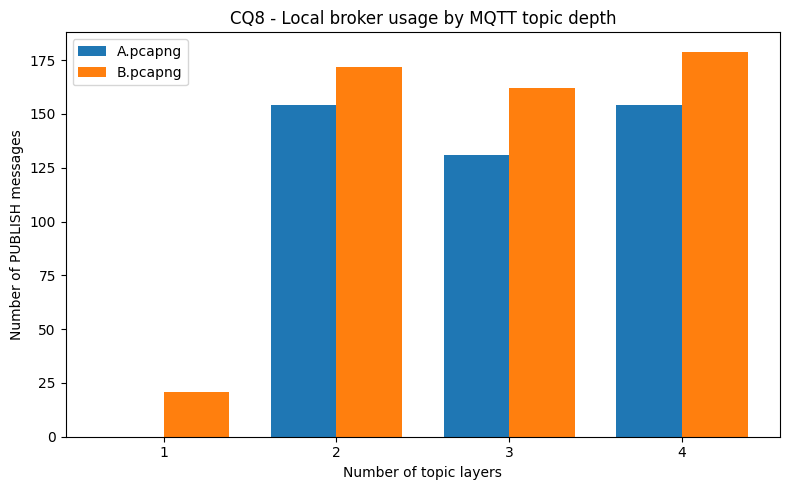

In [ ]:
def build_parser():
    """
    Constructs the ArgumentParser to allow running specific parts of the project via CLI.
    """
    parser = argparse.ArgumentParser(
        description="Combined solutions for parts 1 through 8 with shared packet parsing."
    )
    parser.add_argument(
        "parts",
        nargs="*",
        type=int,
        help="Parts to run. Omit to run all parts.",
    )
    parser.add_argument("--file-a", default=FILE_A, help="Capture file used by parts 1-4 and 8.")
    parser.add_argument("--file-b", default=FILE_B, help="Capture file used by parts 5-8.")
    parser.add_argument(
        "--plot-output",
        default="cq8_histogram.png",
        help="Output image path for part 8 histogram.",
    )
    return parser


def main():
    """
    Main entry point. Evaluates parsed arguments and executes the requested parts of the project.
    Note: For Jupyter Notebook / Google Colab compatibility, `args=[]` is passed.
    """
    parser = build_parser()
    #args = parser.parse_args()
    args = parser.parse_args(args=[])

    selected_parts = args.parts or list(range(1, 9))
    runners = {
        1: lambda: run_part1(args.file_a),
        2: lambda: run_part2(args.file_a),
        3: lambda: run_part3(args.file_a),
        4: lambda: run_part4(args.file_a),
        5: lambda: run_part5(args.file_b),
        6: lambda: run_part6(args.file_b),
        7: lambda: run_part7(args.file_b),
        8: lambda: run_part8(args.file_a, args.file_b, args.plot_output),
    }

    for index, part in enumerate(selected_parts):
        if part not in runners:
            raise SystemExit(f"Unsupported part: {part}")
        if index > 0:
            print()
            print("=" * 72)
            print()
        runners[part]()


if __name__ == "__main__":
    main()
